### This notebook generates figure 4 of the Shahbazi et al. 2026 paper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import cortico_cereb_connectivity.summarize as ccs
import Functional_Fusion.atlas_map as am
import SUITPy as suit

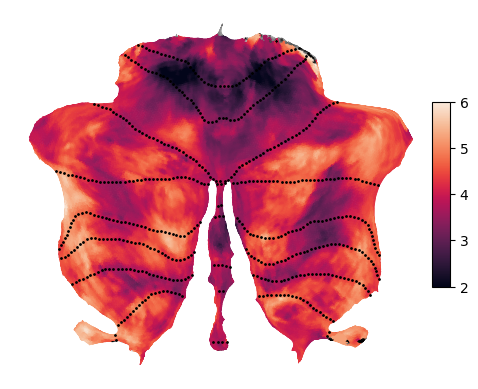

In [11]:
ds_code = ''.join(gl.dscode)
atlas, _ = am.get_atlas('MNISymC3')
ext1 = "A0_global"
NNLS_mo, _ = ccs.get_model(ds_code, 'Icosahedron1002', 'NNLS', ext1, cerebellum_atlas='MNISymC3', norm=True)
conv_NNLS = np.nanmean(NNLS_mo.coef_ > 0, axis=1) * 100

vox_data = suit.vol_to_surf(atlas.data_to_nifti(conv_NNLS), space='MNISymC')
suit.flatmap.plot(vox_data, cmap='rocket', colorbar=True, new_figure=False, cscale=[2, 6]);

plt.savefig(gl.fig_dir + "/fig04_a.pdf", bbox_inches="tight", dpi=300)

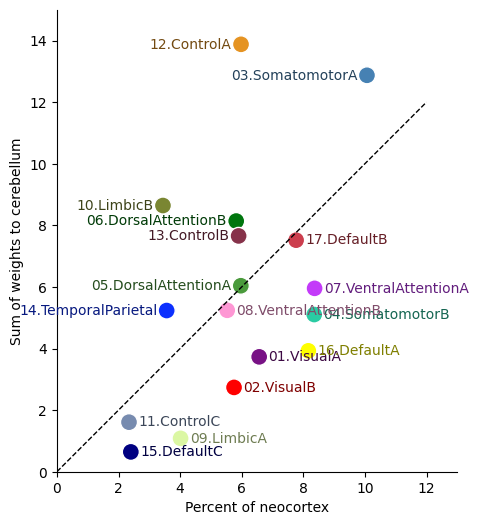

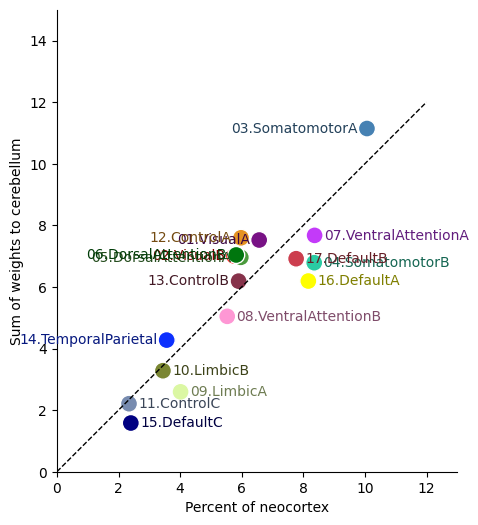

In [10]:
for method in ['nnls', 'ridge']:
    T = pd.read_csv(f'../../tsv/network_weights_yeo_{method}.tsv',sep='\t')
    label_colors = np.array([T.color_r,T.color_g,T.color_b]).T

    plt.figure(figsize=(6,6))
    sns.scatterplot(T, x='cort_size', y='cereb_size', color=label_colors, s=150)
    sns.despine()
    for x,y,label,color in zip(T.cort_size, T.cereb_size, T.name, label_colors):
        if x>y:
            plt.text(x+0.3, y, label, va='center', ha='left', fontsize=10, color=color*0.5)
        else:
            plt.text(x-0.3, y, label, va='center', ha='right', fontsize=10, color=color*0.5)
    ax=plt.gca()
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Percent of neocortex')
    ax.set_ylabel('Sum of weights to cerebellum')
    ax.set_xlim([0,13])
    ax.set_ylim([0,15])
    plt.plot([0,12], [0,12], 'k--', linewidth=1);

    plt.savefig(gl.fig_dir + f"/fig04_b_{method}.pdf", bbox_inches="tight", dpi=300)